In [ ]:
from __future__ import division

import numpy as np
import pandas as pd
import xgboost
import math
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import explained_variance_score, mean_squared_error
from time import time
from sklearn.metrics import r2_score
import os
from sklearn.model_selection import train_test_split

# Machine Learning
from sklearn.ensemble import GradientBoostingRegressor

In [38]:
data = pd.read_csv("data/house_data.csv")

In [39]:
data.head(10)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
5,7237550310,20140512T000000,1225000.0,4,4.50,5420,101930,1.0,0,0,...,11,3890,1530,2001,0,98053,47.6561,-122.005,4760,101930
6,1321400060,20140627T000000,257500.0,3,2.25,1715,6819,2.0,0,0,...,7,1715,0,1995,0,98003,47.3097,-122.327,2238,6819
7,2008000270,20150115T000000,291850.0,3,1.50,1060,9711,1.0,0,0,...,7,1060,0,1963,0,98198,47.4095,-122.315,1650,9711
8,2414600126,20150415T000000,229500.0,3,1.00,1780,7470,1.0,0,0,...,7,1050,730,1960,0,98146,47.5123,-122.337,1780,8113
9,3793500160,20150312T000000,323000.0,3,2.50,1890,6560,2.0,0,0,...,7,1890,0,2003,0,98038,47.3684,-122.031,2390,7570


In [40]:
# Copying data to another dataframe df_train for our convinience so that original dataframe remain intact.
df_train = data.copy()
df_train.rename(columns={"price": "SalePrice"}, inplace=True)

In [41]:
# Now lets see the first five rows of the data
data.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


**STEP 2:  DATA CLEANING AND PREPROCESSING**

In [42]:
print(len(data))
# Check the number of features in the data set
print(len(data.columns))
# Check the data types of each column
print(data.dtypes)

21613
21
id                 int64
date              object
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object


In [43]:
# Check any number of columns with NaN or missing values
print(data.isnull().any().sum(), " / ", len(data.columns))

0  /  21


In [44]:
# Check any number of data points with NaN
print(data.isnull().any(axis=1).sum(), " / ", len(data))

0  /  21613


**STEP 3 : FINDING CORRELATION**

In [45]:
# As id and date columns are not important to predict price so we are discarding it for finding correlation
features = data.iloc[:, 3:].columns.tolist()
target = data.iloc[:, 2].name

In [19]:
num_features = data[features].select_dtypes(include=["int64"]).columns

In [46]:
# Finding Correlation of price with other variables to see how many variables are strongly correlated with price
correlations = {}
for f in features:
    data_temp = data[[f, target]]
    x1 = data_temp[f].values
    x2 = data_temp[target].values
    key = f + " vs " + target
    correlations[key] = pearsonr(x1, x2)[0]

In [47]:
# Printing all the correlated features value with respect to price which is target variable
# Checking Corelation with price
data_correlations = pd.DataFrame(correlations, index=["Value"]).T
data_correlations.loc[
    data_correlations["Value"].abs().sort_values(ascending=False).index
]

,Value
sqft_living vs price,0.702035
grade vs price,0.667434
sqft_above vs price,0.605567
sqft_living15 vs price,0.585379
bathrooms vs price,0.525138
view vs price,0.397293
sqft_basement vs price,0.323816
bedrooms vs price,0.308350
lat vs price,0.307003
waterfront vs price,0.266369


**STEP 4 : EDA or DATA VISUALIZATION **

Let's explore the data

In [24]:
data.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

<Axes: xlabel='sqft_living', ylabel='price'>

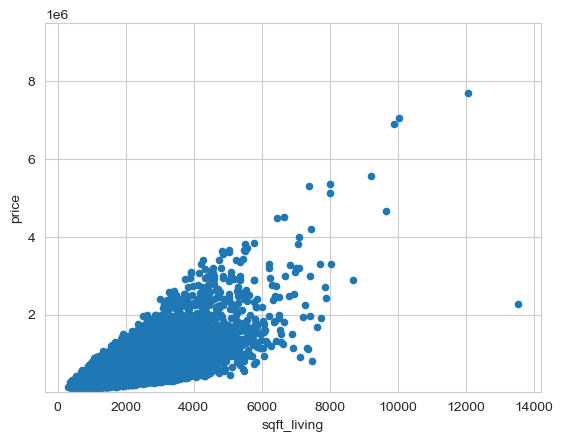

In [48]:
var = "sqft_living"
data = pd.concat([data["price"], data[var]], axis=1)
data.plot.scatter(x=var, y="price", ylim=(3, 9500000))

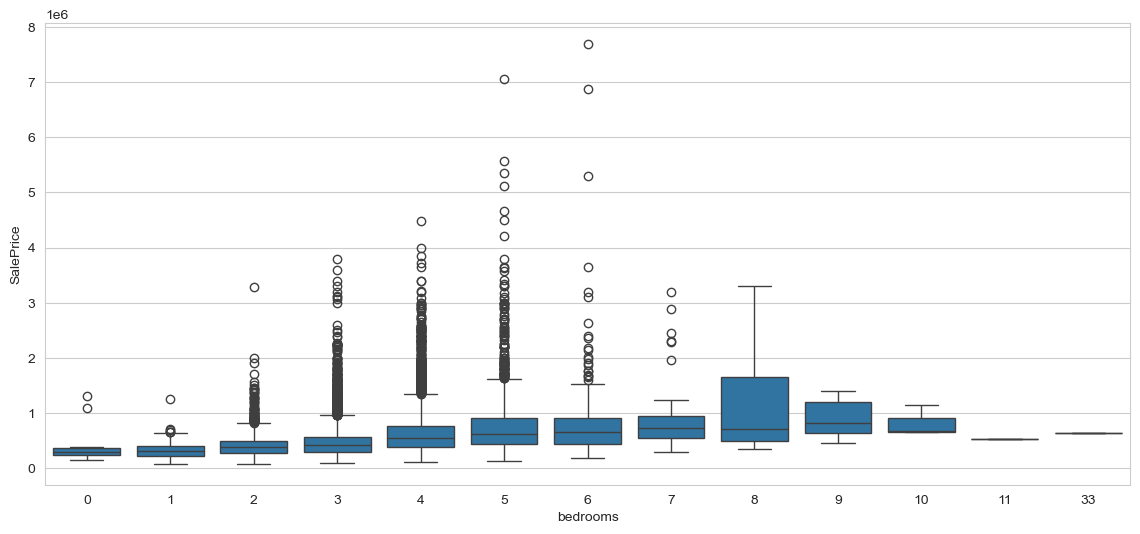

In [49]:
var = "bedrooms"
data = pd.concat([df_train["SalePrice"], df_train[var]], axis=1)
f, ax = plt.subplots(figsize=(14, 6))
fig = sns.boxplot(x=var, y="SalePrice", data=data)

In [50]:
df_train["bathrooms"].value_counts()

bathrooms
2.50    5380
1.00    3852
1.75    3048
2.25    2047
2.00    1930
1.50    1446
2.75    1185
3.00     753
3.50     731
3.25     589
3.75     155
4.00     136
4.50     100
4.25      79
0.75      72
4.75      23
5.00      21
5.25      13
0.00      10
5.50      10
1.25       9
6.00       6
0.50       4
5.75       4
6.75       2
8.00       2
6.25       2
6.50       2
7.50       1
7.75       1
Name: count, dtype: int64

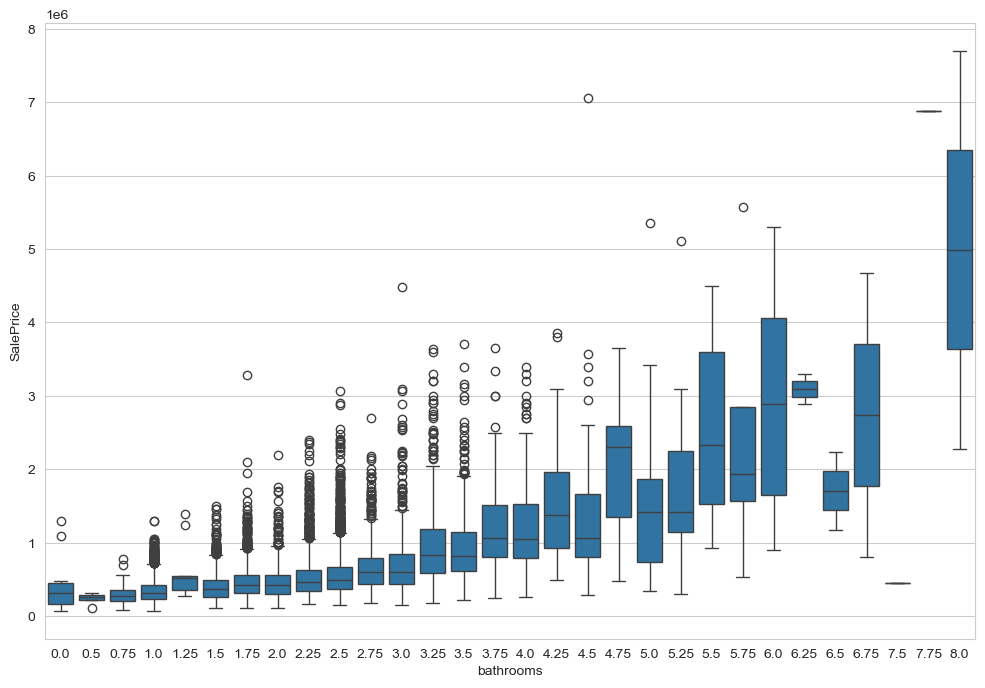

In [51]:
# todo revise subplots
var = "bathrooms"
data = pd.concat([df_train["SalePrice"], df_train[var]], axis=1)
f, ax = plt.subplots(figsize=(12, 8))
fig = sns.boxplot(x=var, y="SalePrice", data=data)

In [52]:
df_train.head(10)

,id,date,SalePrice,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
5,7237550310,20140512T000000,1225000.0,4,4.50,5420,101930,1.0,0,0,...,11,3890,1530,2001,0,98053,47.6561,-122.005,4760,101930
6,1321400060,20140627T000000,257500.0,3,2.25,1715,6819,2.0,0,0,...,7,1715,0,1995,0,98003,47.3097,-122.327,2238,6819
7,2008000270,20150115T000000,291850.0,3,1.50,1060,9711,1.0,0,0,...,7,1060,0,1963,0,98198,47.4095,-122.315,1650,9711
8,2414600126,20150415T000000,229500.0,3,1.00,1780,7470,1.0,0,0,...,7,1050,730,1960,0,98146,47.5123,-122.337,1780,8113
9,3793500160,20150312T000000,323000.0,3,2.50,1890,6560,2.0,0,0,...,7,1890,0,2003,0,98038,47.3684,-122.031,2390,7570


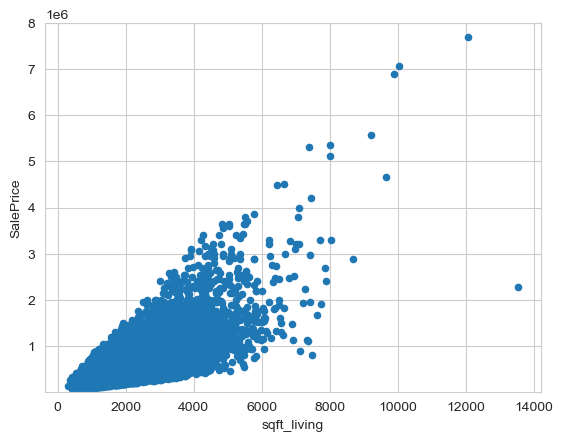

In [54]:
var = "sqft_living"
data = pd.concat([df_train["SalePrice"], df_train[var]], axis=1)
data.plot.scatter(x=var, y="SalePrice", ylim=(3, 8000000));

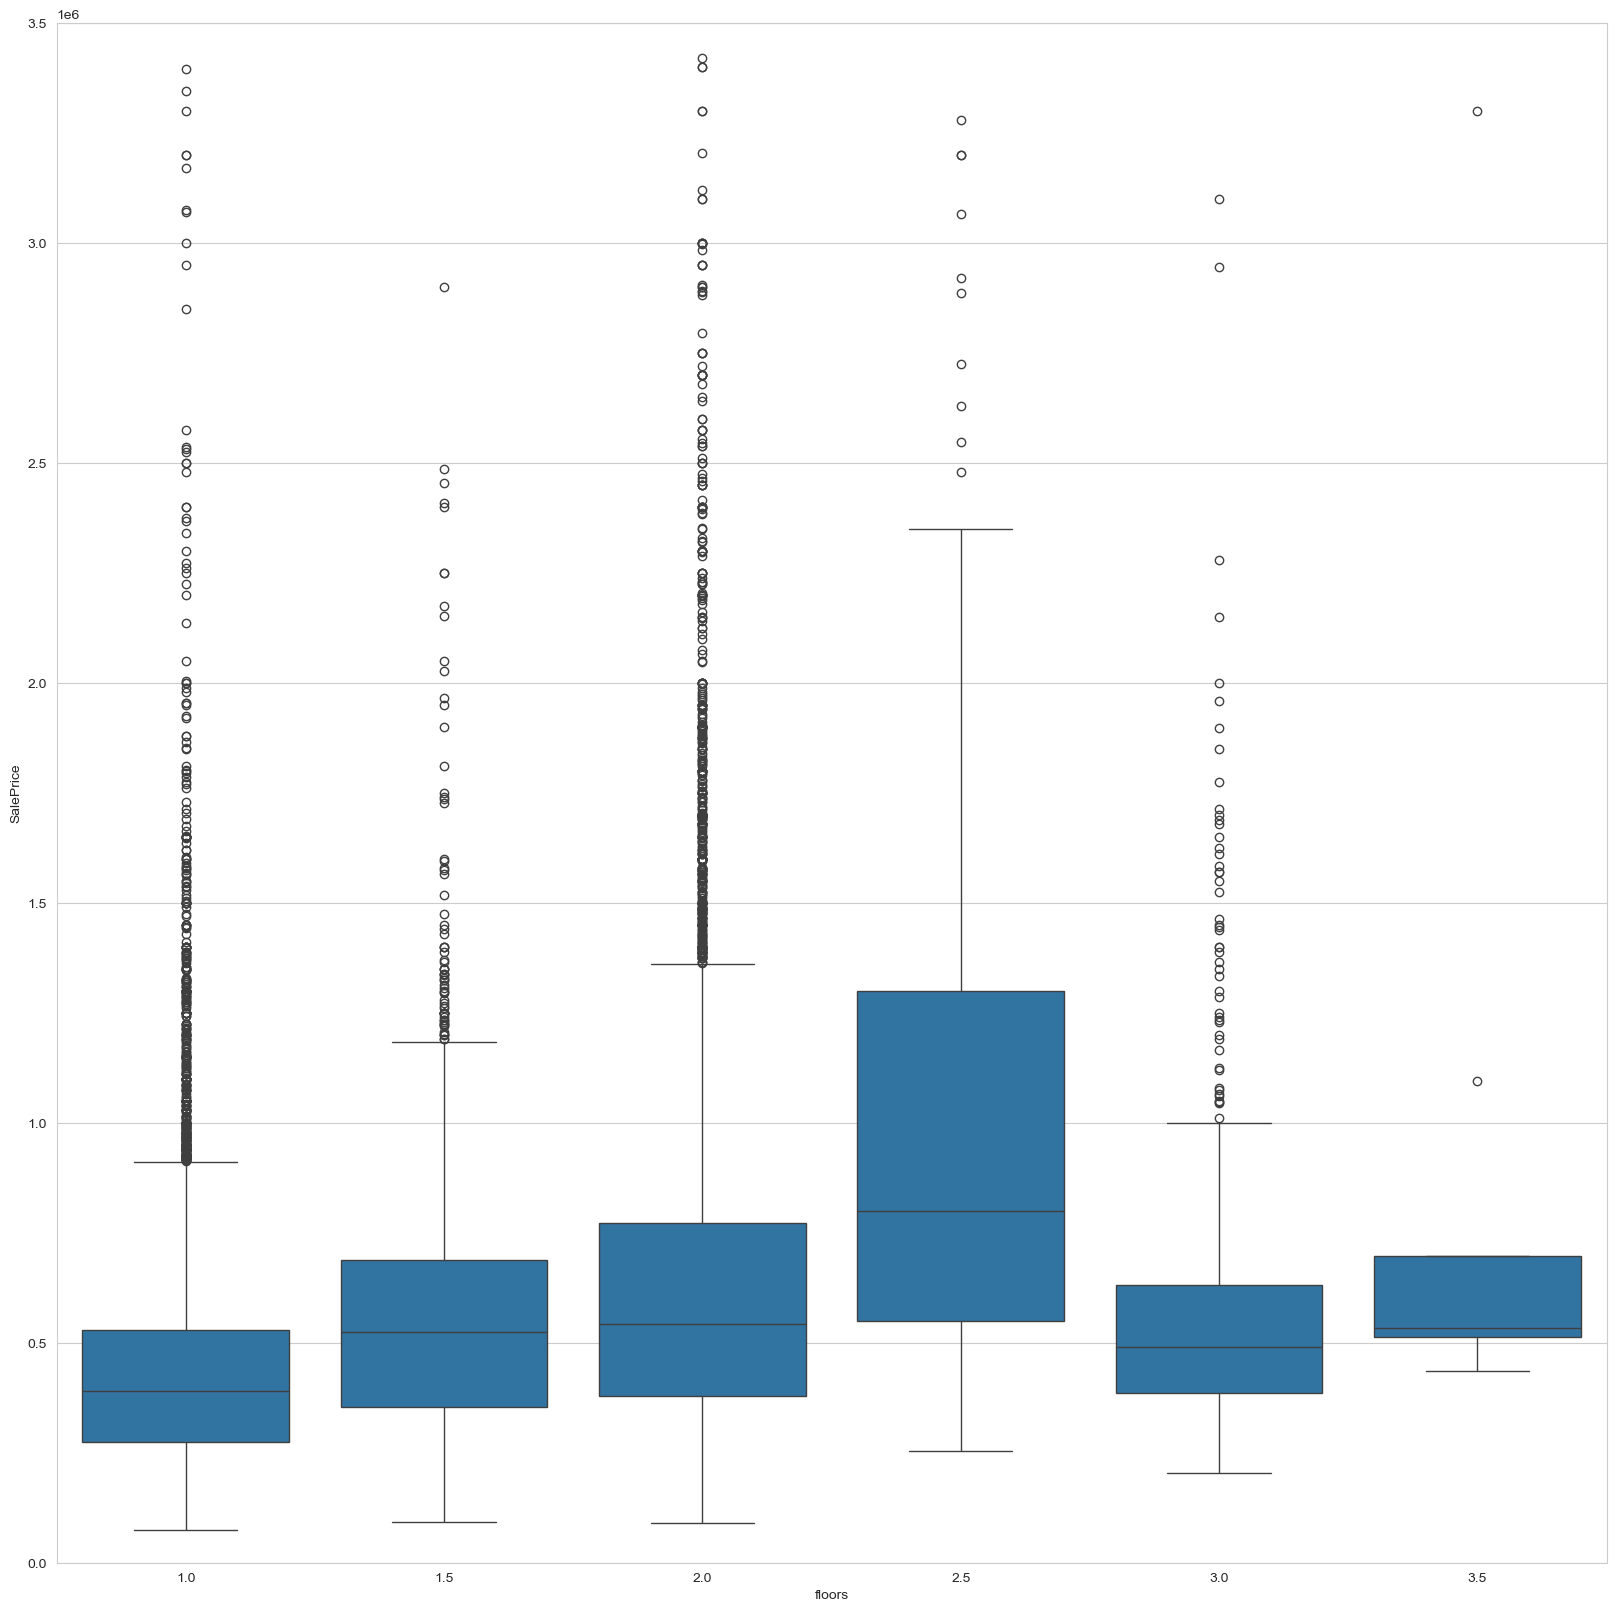

In [55]:
var = "floors"
data = pd.concat([df_train["SalePrice"], df_train[var]], axis=1)
f, ax = plt.subplots(figsize=(20, 20))
fig = sns.boxplot(x=var, y="SalePrice", data=data)
fig.axis(ymin=0, ymax=3500000);

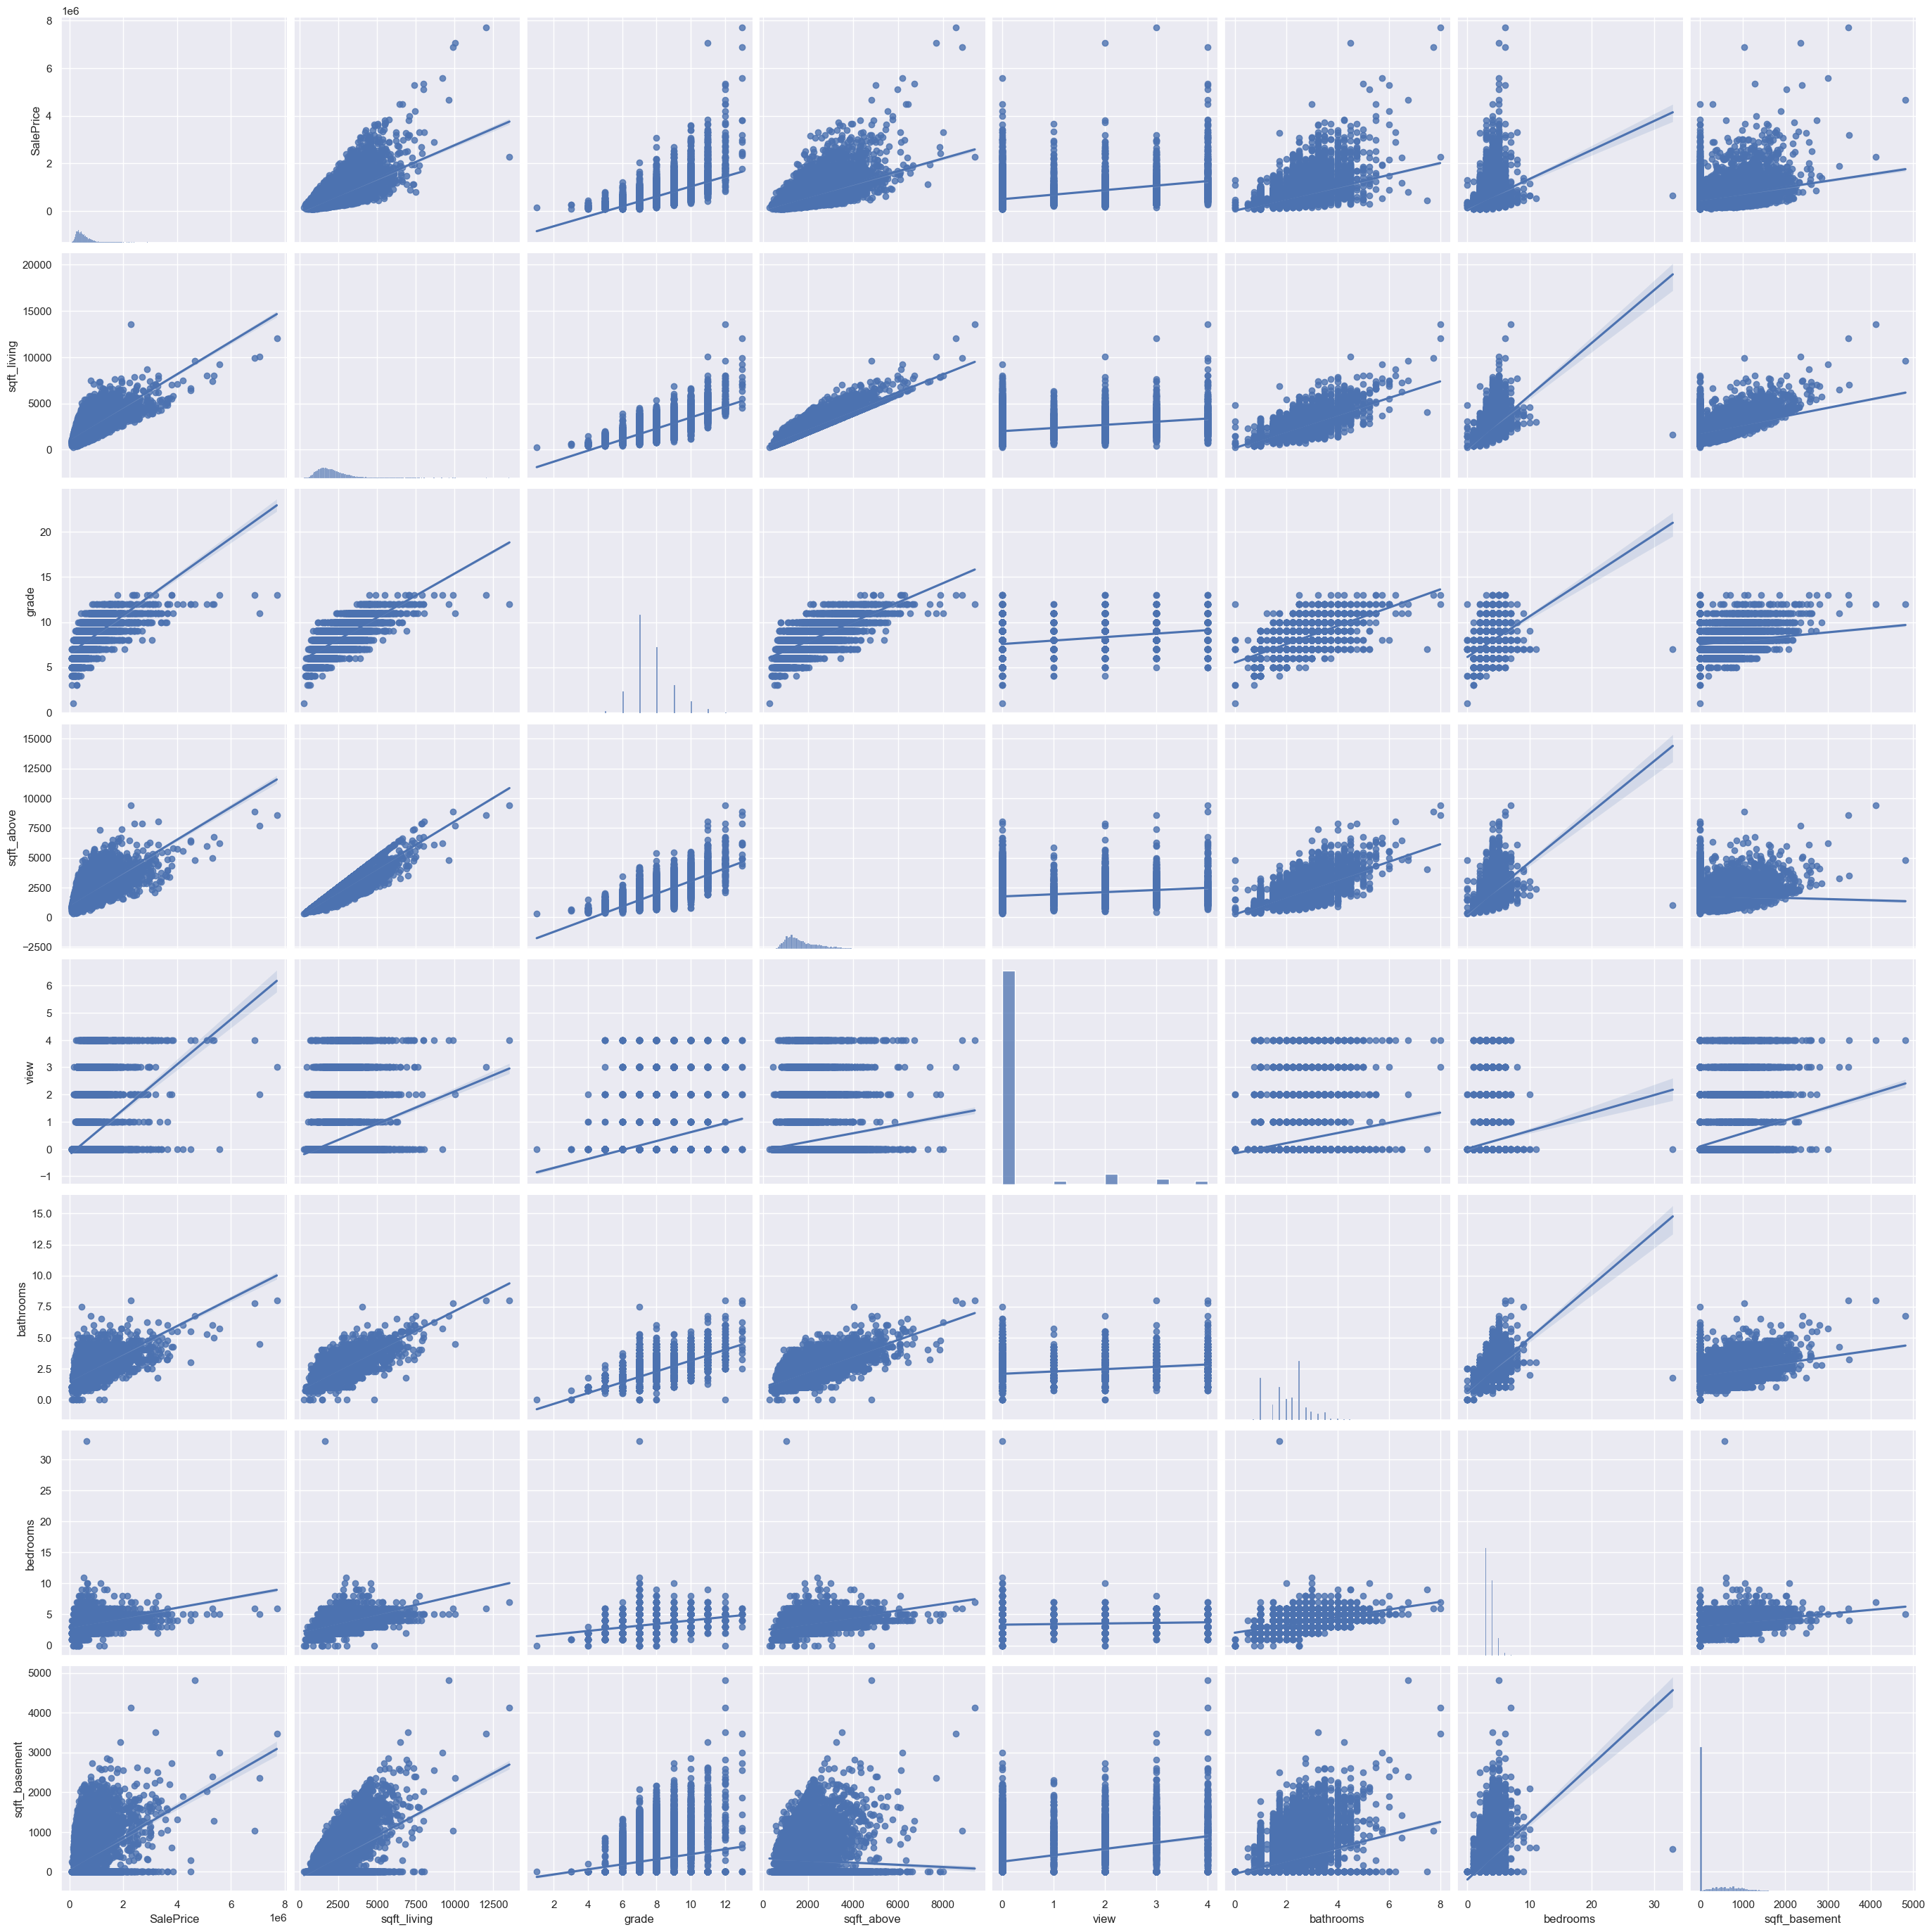

In [57]:
# Pairplots to visualize strong correlation
sns.set()
cols = [
    "SalePrice",
    "sqft_living",
    "grade",
    "sqft_above",
    "view",
    "bathrooms",
    "bedrooms",
    "sqft_basement",
]
sns.pairplot(df_train[cols], height=3.5, kind="reg")
plt.show();

In [58]:
df_train.dtypes

id                 int64
date              object
SalePrice        float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object

In [59]:
filtered_data = df_train[
    [
        "sqft_living",
        "grade",
        "sqft_above",
        "sqft_living15",
        "bathrooms",
        "view",
        "sqft_basement",
        "waterfront",
        "yr_built",
        "lat",
        "bedrooms",
        "long",
    ]
]

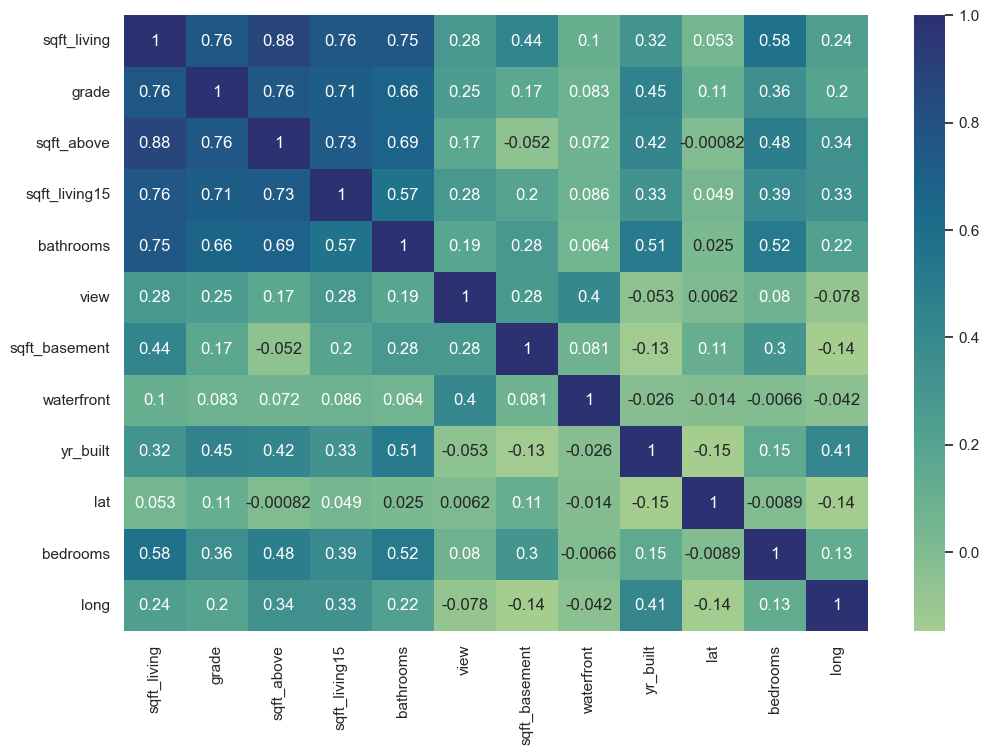

In [61]:
plt.figure(figsize=(12, 8))
sns.heatmap(filtered_data.corr(), annot=True, cmap="crest")
plt.show()

In [66]:
from utilties import utils

In [67]:
import importlib

importlib.reload(utils)

<module 'utilties.utils' from '/Users/deven/Developer/ML_AI/utilties/utils.py'>

In [68]:
utils.variance_inflation(filtered_data, filtered_data.columns)

AttributeError: module 'utilties.utils' has no attribute 'variance_inflation'

In [ ]:
X = filtered_data.values
y = df_train.SalePrice.values

In [ ]:
filtered_data.dtypes

In [ ]:
filtered_data.dtypes

**STEP 5 : SPLITTING DATA INTO TRAINING AND TESTING SET**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)